<a href="https://colab.research.google.com/github/aniii052/AML-lab-24cseaiml052/blob/main/exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving cgpaPRED.xls to cgpaPRED.xls
['.config', 'cgpaPRED.xls', 'sample_data']
Dataset Summary
(379, 5)
SEM 1    0
SEM 2    0
SEM 3    0
SEM 4    0
SEM 5    0
dtype: int64
            SEM 1       SEM 2       SEM 3       SEM 4       SEM 5
count  379.000000  379.000000  379.000000  379.000000  379.000000
mean     5.908707    6.015858    6.103852    6.167546    6.050765
std      3.147572    3.139440    3.078922    3.131259    3.091451
min      0.100000    0.100000    0.130000    0.120000    0.140000
25%      4.080000    4.275000    4.870000    4.990000    4.290000
50%      7.150000    7.240000    7.500000    7.450000    7.420000
75%      8.190000    8.320000    8.225000    8.440000    8.220000
max      9.800000    9.880000    9.730000    9.880000    9.640000


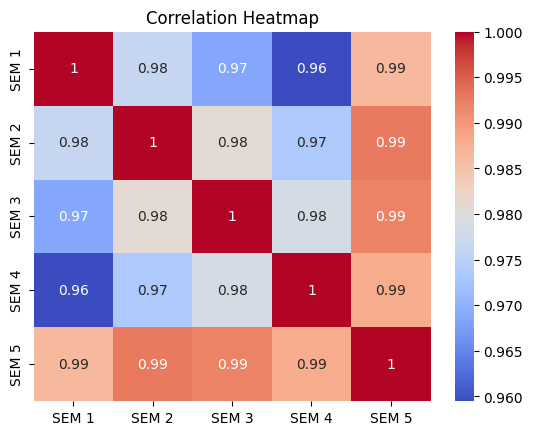

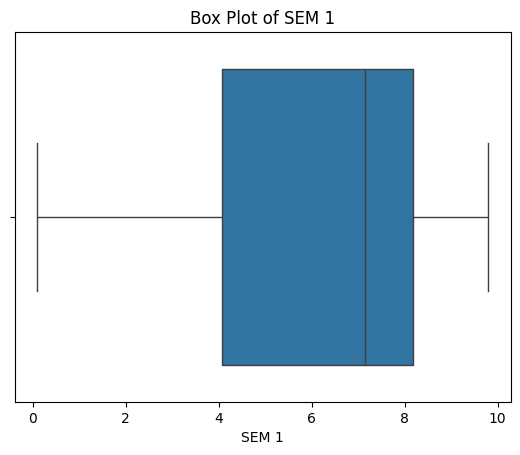

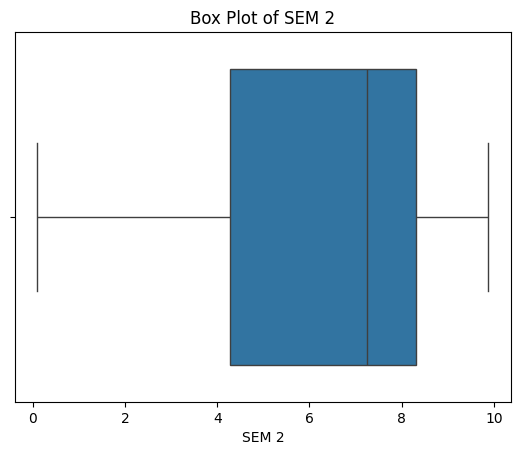

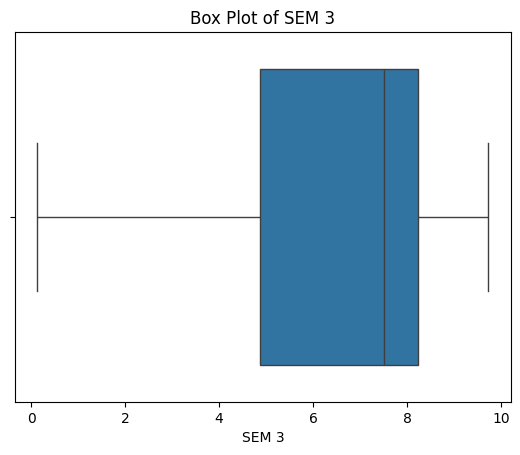

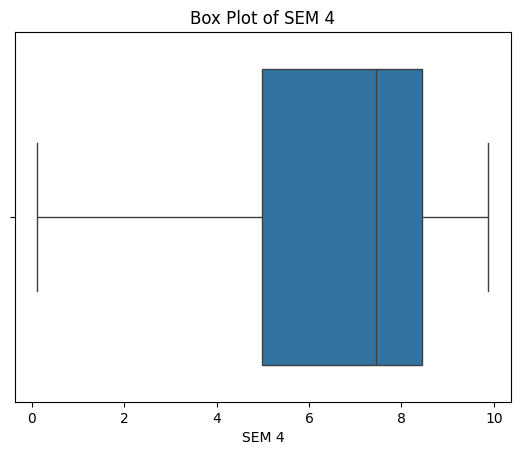

--- Simple Linear Regression Results ---
Equation: y = 0.17 + 0.98 * X1
MAE: 0.25
MSE: 0.12
RMSE: 0.34
R2 Score: 0.99
--- Multiple Linear Regression Results ---
Equation: y = 0.00 + 0.25 * X1 + 0.25 * X2 + 0.25 * X3 + 0.25 * X4
MAE: 0.00
MSE: 0.00
RMSE: 0.00
R2 Score: 1.00


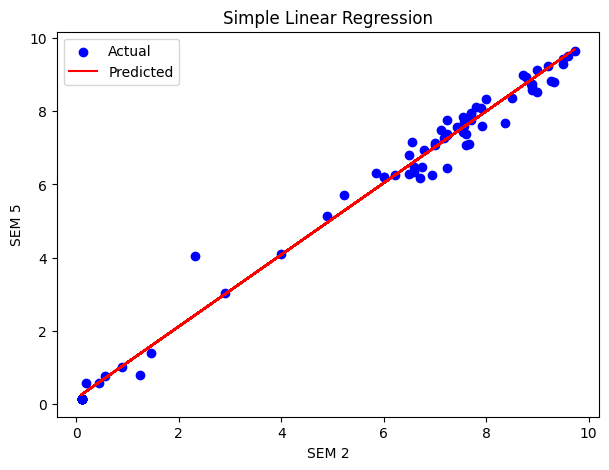

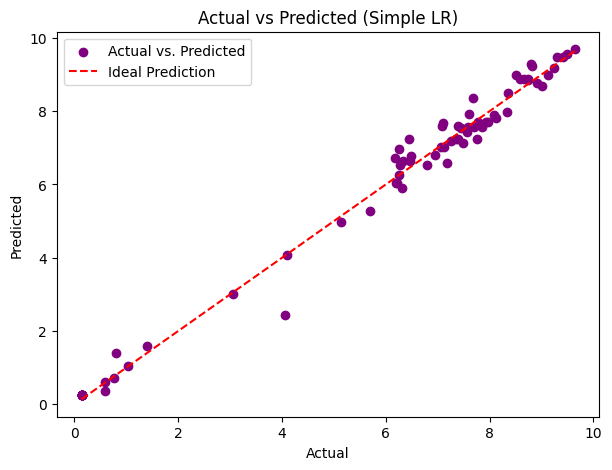

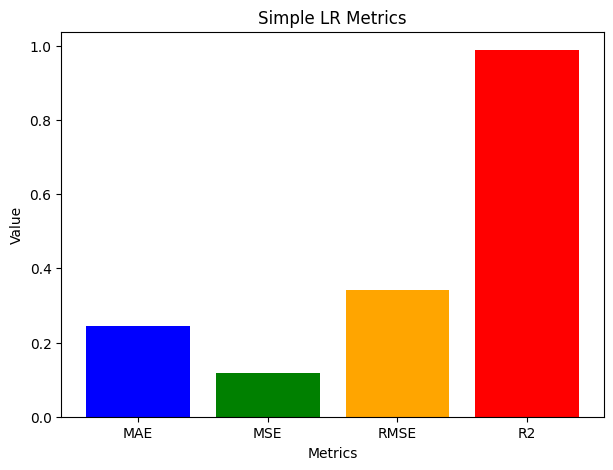

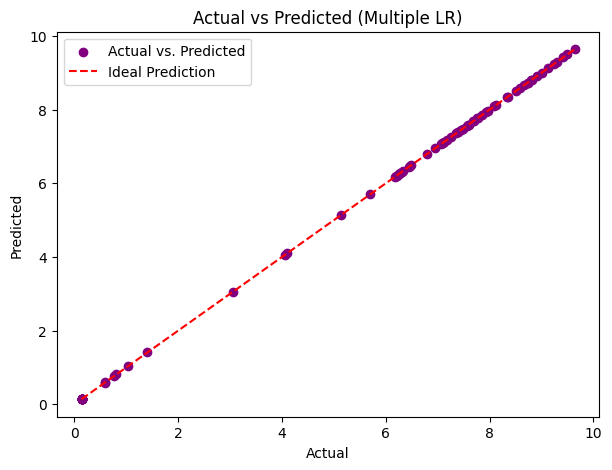

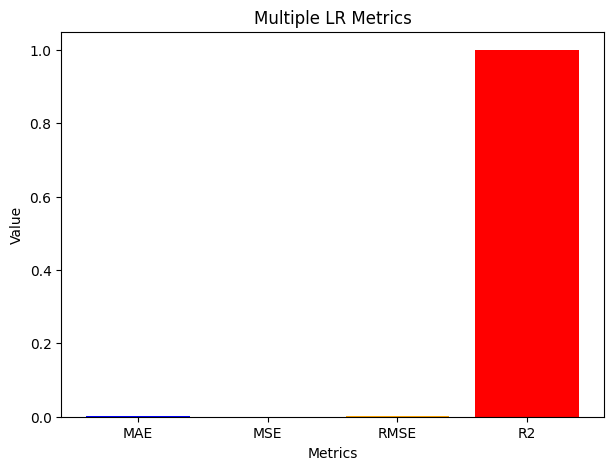

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import files
uploaded = files.upload()
import os

print(os.listdir())
import pandas as pd
def train_and_evaluate(X, y, title):
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(x_train, y_train)

    predictions = model.predict(x_test)

    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    equation = f"y = {model.intercept_:.2f}"
    for i, coef in enumerate(model.coef_):
        equation += f" + {coef:.2f} * X{i+1}"

    print(f"--- {title} Results ---")
    print(f"Equation: {equation}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.2f}")
    return model, x_test, y_test, predictions, [mae, mse, rmse, r2]

def plot_chart(title, x_data, y_data, xlabel, ylabel,
               predictions=None, chart_type="scatter-line"):

    plt.figure(figsize=(7,5))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if chart_type == "scatter-line":
        plt.scatter(x_data, y_data, color="blue", label="Actual")
        plt.plot(x_data, predictions, color="red", label="Predicted")
        plt.legend()

    elif chart_type == "actual-vs-pred":
        plt.scatter(y_data, predictions, color="purple", label="Actual vs. Predicted")
        plt.plot([y_data.min(), y_data.max()],
                 [y_data.min(), y_data.max()],
                 color="red", linestyle='--', label="Ideal Prediction")
        plt.legend()

    elif chart_type == "metrics-bar":
        colors = ['blue', 'green', 'orange', 'red']
        metrics_names = ['MAE', 'MSE', 'RMSE', 'R2']
        plt.bar(metrics_names, y_data, color=colors)

    plt.show()

data = pd.read_excel("cgpaPRED.xls")

print("Dataset Summary")

print(data.shape)
print(data.isnull().sum())
print(data.describe())

features = ["SEM 1", "SEM 2", "SEM 3", "SEM 4"]
X_all = data[features]
y = data["SEM 5"]

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

for col in features:
    sns.boxplot(x=data[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

best_feature = data.corr(numeric_only=True)["SEM 5"].drop("SEM 5").abs().idxmax()

X_simple = data[[best_feature]]

simple_model, x_test_s, y_test_s, pred_s, metrics_s = train_and_evaluate(
    X_simple, y, "Simple Linear Regression"
)

multi_model, x_test_m, y_test_m, pred_m, metrics_m = train_and_evaluate(
    X_all, y, "Multiple Linear Regression"
)

# -------- SIMPLE LINEAR REGRESSION --------
plot_chart(
    "Simple Linear Regression",
    x_test_s[best_feature],
    y_test_s,best_feature,
    "SEM 5",
    predictions=pred_s,
    chart_type="scatter-line"
)

plot_chart(
    "Actual vs Predicted (Simple LR)",
    None,
    y_test_s,
    "Actual",
    "Predicted",
    predictions=pred_s,
    chart_type="actual-vs-pred"
)

plot_chart(
    "Simple LR Metrics",
    None,
    metrics_s,
    "Metrics",
    "Value",
    chart_type="metrics-bar"
)

# -------- MULTIPLE LINEAR REGRESSION --------
plot_chart(
    "Actual vs Predicted (Multiple LR)",
    None,
    y_test_m,
    "Actual",
    "Predicted",
    predictions=pred_m, chart_type="actual-vs-pred"
)

plot_chart(
    "Multiple LR Metrics",
    None,
    metrics_m,
    "Metrics",
    "Value",
    chart_type="metrics-bar"
)